In [2]:
# import patch_numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud # type: ignore
import spacy # type: ignore

In [3]:
# %pip install spacy

In [4]:
# !python -m spacy download en_core_web_sm

In [6]:
url = "https://raw.githubusercontent.com/Jcharis/Bible-NLP-and-ML-using-Python/master/kjv_cleandata.csv"
data = pd.read_csv(url)
data.head()

,Unnamed: 0,id,book,chapter,verse,text
0,0,1001001,Genesis,1,1,In the beginning God created the heaven and th...
1,1,1001002,Genesis,1,2,"And the earth was without form, and void; and ..."
2,2,1001003,Genesis,1,3,"And God said, Let there be light: and there wa..."
3,3,1001004,Genesis,1,4,"And God saw the light, that it was good: and G..."
4,4,1001005,Genesis,1,5,"And God called the light Day, and the darkness..."


In [7]:
# extracting named entities
nlp = spacy.load("en_core_web_sm")

def extract_entities(text:str,entity_type: str = 'PERSON'):
  doc = nlp(text)
  entities = [ent.text for ent in doc.ents if ent.label_ == entity_type]
  return entities

In [8]:
extract_entities("Jesse works with David in Accra","PERSON")

['Jesse', 'David']

In [9]:
data["ner_person"] = data["text"].apply(extract_entities)
data.head()

,Unnamed: 0,id,book,chapter,verse,text,ner_person
0,0,1001001,Genesis,1,1,In the beginning God created the heaven and th...,[]
1,1,1001002,Genesis,1,2,"And the earth was without form, and void; and ...",[]
2,2,1001003,Genesis,1,3,"And God said, Let there be light: and there wa...",[God]
3,3,1001004,Genesis,1,4,"And God saw the light, that it was good: and G...",[]
4,4,1001005,Genesis,1,5,"And God called the light Day, and the darkness...",[]


In [10]:
person_list = [i for item in data['ner_person'].tolist() for i in item]
person_list

['God',
 'God',
 'God',
 'God',
 'God',
 'God',
 'moveth',
 'God',
 'God',
 'moveth',
 'God',
 'Behold',
 'Havilah',
 'God',
 'Adam',
 'Adam',
 'Adam',
 'Adam',
 'Adam',
 'Adam',
 'Yea',
 'Ye',
 'Ye',
 'Ye',
 'Adam',
 'Adam',
 'Adam',
 'Thou',
 'Adam',
 'Eve',
 'God',
 'Behold',
 'Eden Cherubims',
 'Adam',
 'Abel',
 'Abel',
 'Abel',
 'Abel',
 'Cain',
 'Abel',
 'Abel',
 'Abel',
 'findeth',
 'slayeth Cain',
 'Enoch',
 'Enoch',
 'Mehujael',
 'Mehujael',
 'Methusael',
 'Methusael',
 'Jabal',
 'Zillah',
 'Naamah',
 'Lamech',
 'Adam',
 'Seth',
 'Abel',
 'Seth',
 'Enos',
 'Adam',
 'Adam',
 'Adam',
 'Seth',
 'Adam',
 'Seth',
 'Adam',
 'Seth',
 'Enos',
 'Seth',
 'Enos',
 'Enos',
 'Cainan',
 'Cainan',
 'Jared',
 'Enoch',
 'Enoch',
 'Methuselah',
 'Enoch',
 'Enoch',
 'Methuselah',
 'Methuselah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Shem',
 'Japheth',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Shem',
 'Japheth',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',
 'Noah',


In [11]:
def plot_wordcloud(docx):
  my_wordcloud = WordCloud().generate(docx)
  plt.imshow(my_wordcloud,interpolation="bilinear")
  plt.axis("off")
  plt.show()

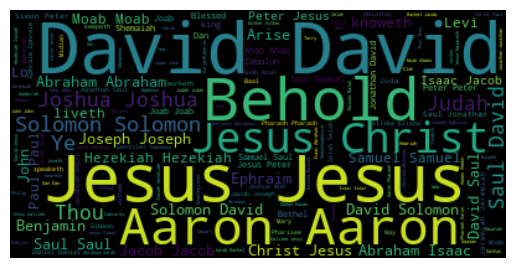

In [12]:
plot_wordcloud(" ".join(person_list))

In [13]:
from collections import Counter
most_common_name = Counter(person_list)
most_common_name.most_common(20)

[('David', 1041),
 ('Jesus', 771),
 ('Saul', 358),
 ('Aaron', 347),
 ('Solomon', 303),
 ('Behold', 290),
 ('Jacob', 280),
 ('Joseph', 248),
 ('Abraham', 247),
 ('Joshua', 214),
 ('Jesus Christ', 184),
 ('Moab', 166),
 ('Paul', 157),
 ('Judah', 149),
 ('Samuel', 142),
 ('Joab', 142),
 ('Peter', 141),
 ('Thou', 131),
 ('Benjamin', 129),
 ('Ye', 128)]

<Axes: >

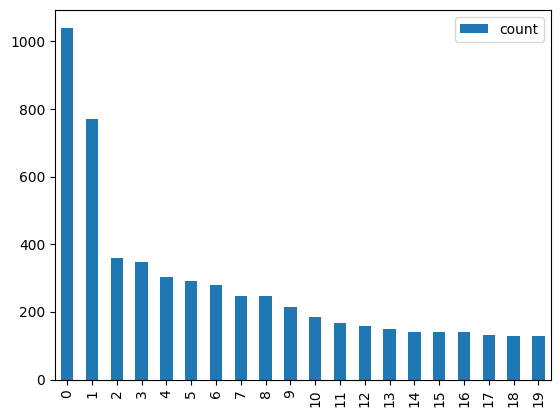

In [14]:
bible_names_data = pd.DataFrame(most_common_name.most_common(20),columns=["names","count"])
bible_names_data.plot(kind="bar")

In [15]:
# import plotly
# print("Plotly version: ", plotly.__version__)

In [16]:
# %pip install --upgrade plotly

In [17]:
# print("Plotly version: ", plotly.__version__)

In [18]:
import plotly.express as px
px.bar(bible_names_data,x="names",y="count")

In [19]:
# Network analysis
import networkx as nx

In [20]:
def get_relationships(clean_data,window_size:int = 5, entity_column:str = 'person'):
  relationships = []
  
  for i in range(clean_data.index[-1]):
    end_i = min(i+5,clean_data.index[-1])
    char_list = sum((clean_data.loc[i:end_i][entity_column]),[])
    
    # Remove duplicated characters that are next to each other
    char_unique = [char_list[i] for i in range(len(char_list)) if (i==0) or char_list[i] != char_list[i-1]]
    
    if len(char_unique) > 1:
      for idx, a in enumerate(char_unique[:-1]):
        b = char_unique[idx + 1]
        relationships.append({"source":a, "target":b})
        
  return relationships 

In [21]:
data["person"] = data['ner_person'].apply(lambda x: [item.split()[0] for item in x])

In [22]:
clean_data = data

In [23]:
relationship_data = get_relationships(clean_data)
relationship_data

[{'source': 'God', 'target': 'moveth'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'God', 'target': 'moveth'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'moveth', 'target': 'God'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'God', 'target': 'Behold'},
 {'source': 'God', 'target': 'Adam'},
 {'source': 'God', 'target': 'Adam'},
 {'s

In [24]:
relationship_data = pd.DataFrame(relationship_data)
relationship_data.head()

,source,target
0,God,moveth
1,God,moveth
2,God,moveth
3,God,moveth
4,moveth,God


In [25]:
relationship_data = pd.DataFrame(np.sort(relationship_data.values,axis=1),columns=relationship_data.columns)
relationship_data

,source,target
0,God,moveth
1,God,moveth
2,God,moveth
3,God,moveth
4,God,moveth
...,...,...
52242,David,Jesus
52243,David,heareth
52244,Jesus,heareth
52245,Jesus,heareth


In [26]:
relationship_data["value"] = 1
relationship_data = relationship_data.groupby(["source","target"],sort=False,as_index=False).sum()
relationship_data

,source,target,value
0,God,moveth,17
1,Behold,God,12
2,Adam,God,5
3,Adam,Yea,3
4,Ye,Yea,6
...,...,...,...
5344,Alpha,Behold,5
5345,Lamb,worketh,6
5346,Omega,loveth,4
5347,loveth,maketh,6


In [27]:
# creating a network graph
bible_graph = nx.from_pandas_edgelist(relationship_data,source="source",target="target",edge_attr="value",create_using=nx.Graph())
bible_graph

In [28]:
nx.degree(bible_graph)

DegreeView({'God': 22, 'moveth': 5, 'Behold': 162, 'Adam': 18, 'Yea': 23, 'Ye': 93, 'Thou': 67, 'Eve': 4, 'Eden': 3, 'Abel': 11, 'Cain': 1, 'findeth': 22, 'slayeth': 3, 'Enoch': 10, 'Mehujael': 2, 'Methusael': 2, 'Jabal': 2, 'Zillah': 2, 'Naamah': 9, 'Lamech': 2, 'Seth': 3, 'Enos': 4, 'Cainan': 2, 'Jared': 2, 'Methuselah': 2, 'Noah': 16, 'Shem': 10, 'Japheth': 6, 'Canaan': 13, 'Cursed': 7, 'Blessed': 40, 'Javan': 5, 'Tiras': 2, 'Gomer': 4, 'Ashkenaz': 2, 'Riphath': 3, 'Kittim': 2, 'Cush': 8, 'Mizraim': 1, 'Havilah': 7, 'Sabtechah': 2, 'Nimrod': 3, 'Babel': 2, 'Erech': 2, 'Accad': 2, 'Calneh': 3, 'Asshur': 12, 'Nineveh': 13, 'Rehoboth': 4, 'Calah': 3, 'Ludim': 3, 'Lehabim': 3, 'Philistim': 2, 'Sidon': 10, 'Heth': 8, 'Girgasite': 2, 'Gomorrah': 16, 'Lasha': 2, 'Eber': 9, 'Aram': 12, 'Gether': 2, 'Peleg': 4, 'Hazarmaveth': 2, 'Jerah': 3, 'Hadoram': 5, 'Uzal': 3, 'Diklah': 2, 'Abimael': 2, 'Jobab': 13, 'Salah': 2, 'Reu': 3, 'Nahor': 4, 'Terah': 4, 'Sarai': 3, 'Bethel': 35, 'Hai': 2, 'Phara

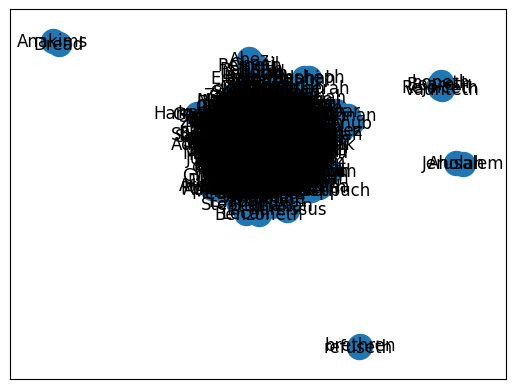

In [30]:
nx.draw_networkx(bible_graph)

In [51]:
# custom network plot
# from visualiser import GraphVisualization
import visualizer

In [52]:
# import networkx as nx
from visualiser import GraphVisualization

# G = nx.karate_club_graph()
# pos = nx.spring_layout(G)

# vis = GraphVisualization(G, pos)
# fig = vis.create_figure(height=800, width=800, showlabel=True)
# fig.show()


In [53]:
def plot_network(my_graph,**kwargs):
  default_kwargs = {
    "node_size":10,
    "node_border_width":1,
    "edge_width":0.5,
    "node_color":"blue"
  }
  
  default_kwargs.update(kwargs)
  
  pos = nx.spring_layout(my_graph,iterations=20)
  vis = GraphVisualization(my_graph,pos,**default_kwargs)
  fig = vis.create_figure(height=800,width=800,showlabel=False)
  return fig

In [55]:
# plot_network(bible_graph)

In [56]:

## Community Detection
communities = nx.community.louvain_communities(bible_graph)

In [57]:
len(communities)

18

In [58]:
# Function to create node color list based on communities
color_map_lists = ['Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
color_map_list = ['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgrey', 'darkgreen', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'grey', 'green', 'greenyellow', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgrey', 'lightgreen', 'lightpink', 'lightsalmon', 'lightseagreen', 'lightskyblue', 'lightslategray', 'lightslategrey', 'lightsteelblue', 'lightyellow', 'lime', 'limegreen', 'linen', 'magenta', 'maroon', 'mediumaquamarine', 'mediumblue', 'mediumorchid', 'mediumpurple', 'mediumseagreen', 'mediumslateblue', 'mediumspringgreen', 'mediumturquoise', 'mediumvioletred', 'midnightblue', 'mintcream', 'mistyrose', 'moccasin', 'navajowhite', 'navy', 'oldlace', 'olive', 'olivedrab', 'orange', 'orangered', 'orchid', 'palegoldenrod', 'palegreen', 'paleturquoise', 'palevioletred', 'papayawhip', 'peachpuff', 'peru', 'pink', 'plum', 'powderblue', 'purple', 'red', 'rosybrown', 'royalblue', 'rebeccapurple', 'saddlebrown', 'salmon', 'sandybrown', 'seagreen', 'seashell', 'sienna', 'silver', 'skyblue', 'slateblue', 'slategray', 'slategrey', 'snow', 'springgreen', 'steelblue', 'tan', 'teal', 'thistle', 'tomato', 'turquoise', 'violet', 'wheat', 'white', 'whitesmoke', 'yellow', 'yellowgreen']
def create_community_node_colors(graph, communities):
  number_of_colors = len(communities)
  node_colors = [color_map_list[i] for i in range(number_of_colors)]
  community_map = {node: i for i, comm in enumerate(communities) for node in comm}
  return [node_colors[community_map[node]] for node in graph.nodes()]

In [61]:
node_colors = create_community_node_colors(bible_graph,communities)
# adding the community attribute to the graph
nx.set_node_attributes(bible_graph,communities,'group')
node_colors

['aqua',
 'aqua',
 'aqua',
 'aliceblue',
 'aqua',
 'coral',
 'aqua',
 'coral',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'coral',
 'blanchedalmond',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'azure',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'coral',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aqua',
 'aqua',
 'aqua',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'coral',
 'aliceblue',
 'aliceblue',
 'beige',
 'beige',
 'aliceblue',
 'beige',
 'beige',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aliceblue',
 'aqua',
 'aqua',
 'aqua',
 'aqua',
 'aqua',
 'aqua',
 'beige',
 'aquamarine',
 '

In [63]:
# plot_network(bible_graph,node_colors)

In [64]:
node_degree = dict(bible_graph.degree)
node_degree

{'God': 22,
 'moveth': 5,
 'Behold': 162,
 'Adam': 18,
 'Yea': 23,
 'Ye': 93,
 'Thou': 67,
 'Eve': 4,
 'Eden': 3,
 'Abel': 11,
 'Cain': 1,
 'findeth': 22,
 'slayeth': 3,
 'Enoch': 10,
 'Mehujael': 2,
 'Methusael': 2,
 'Jabal': 2,
 'Zillah': 2,
 'Naamah': 9,
 'Lamech': 2,
 'Seth': 3,
 'Enos': 4,
 'Cainan': 2,
 'Jared': 2,
 'Methuselah': 2,
 'Noah': 16,
 'Shem': 10,
 'Japheth': 6,
 'Canaan': 13,
 'Cursed': 7,
 'Blessed': 40,
 'Javan': 5,
 'Tiras': 2,
 'Gomer': 4,
 'Ashkenaz': 2,
 'Riphath': 3,
 'Kittim': 2,
 'Cush': 8,
 'Mizraim': 1,
 'Havilah': 7,
 'Sabtechah': 2,
 'Nimrod': 3,
 'Babel': 2,
 'Erech': 2,
 'Accad': 2,
 'Calneh': 3,
 'Asshur': 12,
 'Nineveh': 13,
 'Rehoboth': 4,
 'Calah': 3,
 'Ludim': 3,
 'Lehabim': 3,
 'Philistim': 2,
 'Sidon': 10,
 'Heth': 8,
 'Girgasite': 2,
 'Gomorrah': 16,
 'Lasha': 2,
 'Eber': 9,
 'Aram': 12,
 'Gether': 2,
 'Peleg': 4,
 'Hazarmaveth': 2,
 'Jerah': 3,
 'Hadoram': 5,
 'Uzal': 3,
 'Diklah': 2,
 'Abimael': 2,
 'Jobab': 13,
 'Salah': 2,
 'Reu': 3,
 'Nahor

In [65]:

# Find degree of centrality
degree_centrality = nx.degree_centrality(bible_graph)
degree_centrality

{'God': 0.011885467314964884,
 'moveth': 0.002701242571582928,
 'Behold': 0.08752025931928688,
 'Adam': 0.009724473257698542,
 'Yea': 0.01242571582928147,
 'Ye': 0.050243111831442464,
 'Thou': 0.036196650459211235,
 'Eve': 0.0021609940572663426,
 'Eden': 0.001620745542949757,
 'Abel': 0.005942733657482442,
 'Cain': 0.0005402485143165856,
 'findeth': 0.011885467314964884,
 'slayeth': 0.001620745542949757,
 'Enoch': 0.005402485143165856,
 'Mehujael': 0.0010804970286331713,
 'Methusael': 0.0010804970286331713,
 'Jabal': 0.0010804970286331713,
 'Zillah': 0.0010804970286331713,
 'Naamah': 0.004862236628849271,
 'Lamech': 0.0010804970286331713,
 'Seth': 0.001620745542949757,
 'Enos': 0.0021609940572663426,
 'Cainan': 0.0010804970286331713,
 'Jared': 0.0010804970286331713,
 'Methuselah': 0.0010804970286331713,
 'Noah': 0.00864397622906537,
 'Shem': 0.005402485143165856,
 'Japheth': 0.003241491085899514,
 'Canaan': 0.007023230686115613,
 'Cursed': 0.0037817396002160996,
 'Blessed': 0.021609940

In [67]:
degree_data = pd.DataFrame.from_dict(degree_centrality,orient="index",columns=["centrality"])
degree_data

,centrality
God,0.011885
moveth,0.002701
Behold,0.087520
Adam,0.009724
Yea,0.012426
...,...
Antipas,0.000540
Wormwood,0.000540
Write,0.001621
Alleluia,0.000540


In [69]:
import plotly.express as px
degree_df = degree_data.sort_values('centrality', ascending=False)
fig2 = px.bar(degree_df.head(15),y="centrality", x=degree_df.head(15).index)
fig2.show()

In [70]:
# What is the shortest connection between two people in the bible
nx.shortest_path(bible_graph,"David","Paul")

['David', 'Saul', 'Paul']

In [73]:
# What is the shortest connection between two people in the bible
nx.shortest_path(bible_graph,"Joseph","Jesus")

['Joseph', 'Jesus']

In [74]:
# What is the shortest connection between two people in the bible
nx.shortest_path(bible_graph,"David","Jesse")

['David', 'Jesse']

In [75]:
# saving the model to a file
import pickle

with open("bible_graph.pickle","wb") as f:
  pickle.dump(bible_graph,f)

In [76]:

import pandas as pd
import numpy as np
import spacy
import networkx as nx

class SocialNetworkAnalyzer():
  def __init__(self, model="en_core_web_sm"):
    self.nlp = spacy.load(model)
  
  def extract_entities(self, text: str, entity_type: str = "PERSON"):
    doc = self.nlp(text)
    entities = [ent.text for ent in doc.ents if ent.label_ == entity_type]
    return entities
  
  def get_relationships(self, df, window_size: int = 5, entity_column: str = "person"):
    relationships = []

    for i in range(df.index[-1]):
      end_i = min(i+5, df.index[-1])
      char_list = sum((df.loc[i: end_i][entity_column]), [])
      
      char_unique = [char_list[i] for i in range(len(char_list)) 
                      if (i==0) or char_list[i] != char_list[i-1]]
      
      if len(char_unique) > 1:
        for idx, a in enumerate(char_unique[:-1]):
          b = char_unique[idx + 1]
          relationships.append({"source": a, "target": b})
    return relationships
  
  def analyze(self, df, entity_column="person"):
    df[entity_column] = df[f"ner_{entity_column}"].apply(lambda x: [item.split()[0] for item in x])
    relationships = self.get_relationships(df, entity_column=entity_column)
    relationship_df = pd.DataFrame(relationships)
    relationship_df = pd.DataFrame(np.sort(relationship_df.values, axis = 1), columns = relationship_df.columns)
    relationship_df["value"] = 1
    relationship_df = relationship_df.groupby(["source","target"], sort=False, as_index=False).sum()
    return relationship_df
  
  def create_network_graph(self, relationship_df):
    return nx.from_pandas_edgelist(relationship_df, source="source", target="target", edge_attr="value", create_using=nx.Graph())